열 삭제하기

In [2]:
import gdown

gdown.download('https://bit.ly/3RhoNho', 'ns_202104.csv', quiet=False) # ns_202104.csv 다운

Downloading...
From: https://bit.ly/3RhoNho
To: /content/ns_202104.csv
100%|██████████| 57.6M/57.6M [00:00<00:00, 96.7MB/s]


'ns_202104.csv'

In [3]:
import pandas as pd

ns_df = pd.read_csv('ns_202104.csv', low_memory=False)
ns_df.head() # 처음 다섯 개 행

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


마지막 'Unnnamed:13'열은 CSV파일 각 라인의 끝에 콤마(,)가 있어서 판다스가 자동으로 추가한 것! 불필요한 열이므로 삭제하는 것이 좋다!!

In [4]:
ns_book = ns_df.loc[:, '번호':'등록일자'] # 번호 부터 등록일자 열 까지 행
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


이미 배운 loc메서드에 슬라이싱을 사용하면 다음과 같이 '번호'열부터'등록일자'열까지 선택하여 새로운 데이터프레임을 만들 수 있다.

이방법이 편리하긴 하지만 중간에 있는'부가기호'열을 제외하고 선택하려면 어떻게 해야 할까요? 중간에 있는 열을 제외하려면 슬라이싱을 사용하기 어렵다. 이럴때는 **불리언배열**(boolean array)을 사용하면 쉽게 원하는 열만 선택할 수 있다.

In [5]:
print(ns_df.columns) # ns_df의 열

Index(['번호', '도서명', '저자', '출판사', '발행년도', 'ISBN', '세트 ISBN', '부가기호', '권',
       '주제분류번호', '도서권수', '대출건수', '등록일자', 'Unnamed: 13'],
      dtype='object')


columns속석은 판다스의 Index클래스 객체입니다. 이 객체의 원소는 파이썬의 리스트처럼 숫자 인덱스로 참조할 수 있다. 예를 들어 첫 번째 열 이름인 '번호'를 선택하려면 다음과 같이 쓸 수 있다.

In [6]:
print(ns_df.columns[0]) # ns_df의 열의 첫번째: 번호

번호


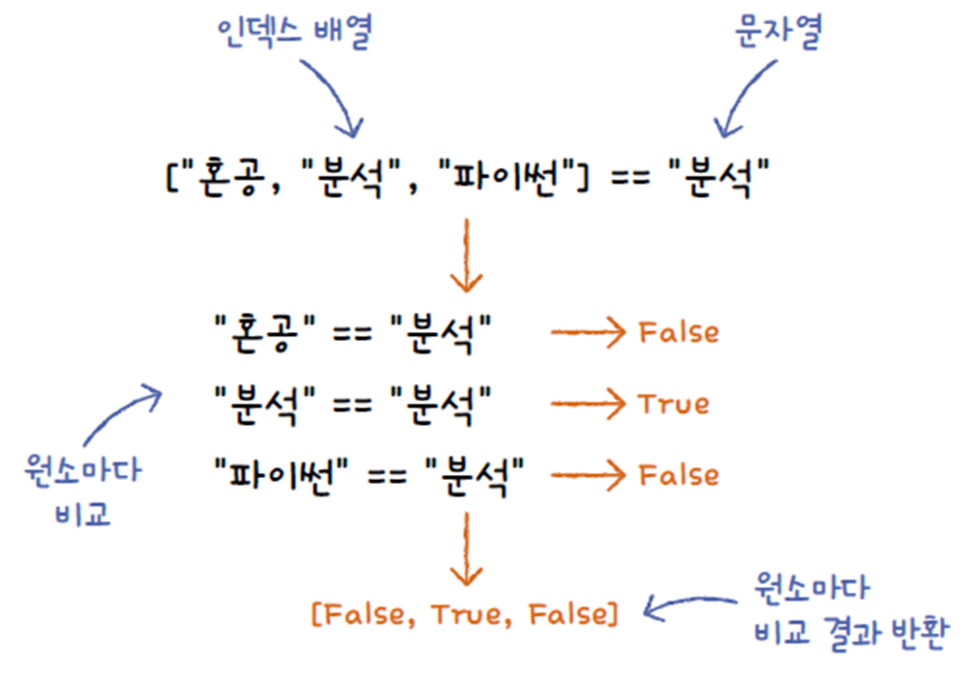

In [7]:
ns_df.columns != 'Unnamed: 13' # Unnamed: 13 이 아닌 열은 무엇인가를 불리언 배열로

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False])

원소별 비교를 활용하여 'Unnamed:13'열이 아닌 것을 표시하는 배열을 마들면 위와 같다! 결과는 넘파이배열(Numpy array}입니다. 지금은 넘파이 배열을 파이썬 리스트와 비슷한것으로 생각해도 좋다. 원소별 비교 연산으로 불리언 배열을 얻었다. 이를 selected_columns변수에 저장하고 판다스 데이터프레임의 loc메서드에 전달하면 True인 열의 행만 선택할 수 있다!




In [8]:
selected_columns = ns_df.columns != 'Unnamed: 13' # unnamed 13 이 아닌 열
ns_book = ns_df.loc[:, selected_columns] # True 인 열의 모든 행 선택
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


이번에는 데이터프레임 중간에 있는 '부가기호'열을 제외해 보겠습니다.

In [9]:
selected_columns = ns_df.columns != '부가기호' # 부가기호가 아닌 열
ns_book = ns_df.loc[:, selected_columns] # 부가기호가 아닌 열만 저장
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,1,0,2021-03-19,NaN


이번에는 데이터프레임의 메서드를 사용하여 열을 삭제! 판다스에서는 데이터프레임의 행이나 열을 삭제하는 drop()메서드를 제공 drop()메서드로 열을 삭제하려면 첫 번째 매개변수에 삭제하려는 열 이름을 전달하고 axis매개변수를 1로 지정!

In [10]:
ns_book = ns_df.drop('Unnamed: 13', axis=1) # 삭제하려는 열의 이름과 axis 매개벼누에 1을 지정하면 열을 삭제
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [11]:
ns_book = ns_df.drop(['부가기호','Unnamed: 13'], axis=1) # 부가기호도 뺴기
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,1,0,2021-03-19


지금까지는 ns_df데이터프레임에서 열을 삭제한 결과를 ns_book이라는 변수에 저장! drop()메서드에 inplace매개변수를 True로 지정하면 현재 선택한 데이터프레임을 바로 수정할 수도있습니다. 앞서 생성한 ns_book데이터프레임의 '주제분류번호'열을 삭제해 보자.

In [12]:
ns_book.drop('주제분류번호', axis=1, inplace=True) # 데이터프레임에 덮어 씌움
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,1,0,2021-03-19


새로운 변수를 만들어 데이터프레임 수정 결과를 반환하지않고도 ns_book데이터프레임에서 '주제분류번호'열을 삭제!

판다스는 비어있는 값을 NaN으로 표시합니다. drop()메서드와 비슷한 dropna()메서드는 기본적으로 NaN이 하나 이상 포함된 행이나 열을 삭제, axis=1로 지정하여 ns_df데이터프레임에서 NaN이 포함된 열을 삭제! 14개의 열이 5개로 확 줄어들었다. 삭제된 열에는 NaN이 적어도 하나 이상있었나 봅니다.

In [13]:
ns_book = ns_df.dropna(axis=1) # 비어있는 값이 존재한다면 그 열을 아예 삭제하는 식으로 전체 열 중 비어있는 값 있는 열 빼기
ns_book.head()

,번호,ISBN,도서권수,대출건수,등록일자
0,1,9788937444319,1,0,2021-03-19
1,2,9791190123969,1,0,2021-03-19
2,3,9788968332982,1,0,2021-03-19
3,4,9788970759906,1,0,2021-03-19
4,5,9788934990833,1,0,2021-03-19


모든 값이 NaN인 열을 삭제하려면 dropna()메서드에 how매개변수를 'all'로 지정하면 됩니다.

In [14]:
ns_book = ns_df.dropna(axis=1, how='all') # 모든 값이 비어있는 열만 삭제하려면 -> how='all'로 지정해서 삭제
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


지금까지 열을 삭제하는 방법을 알아봤습니다. loc메서드로 필요한 열을 선택하려면 슬라이스 연산자나 불리언 배열을 사용할 수 있다. 이 두가지가 유일한 방법은 아니다. drop()메서드로 열을 삭제하려면 axis=1과 삭제하려는 열을 지정! 삭제할 열이 여러개일 때는 열 이름을 리스트로 전달할 수 있다. 또는 dropna()메서드에 axis=1을 지정하면 NaN이 들어있는 열을 삭제할 수 있다.

행 삭제

axis=0으로 지정하면 행 삭제 가능, 기본값은 0

이번에는 행을 삭제하는 방법을 알아보겠다. 행을 삭제할 때도 drop()메서드를 사용할 수 있다. axis매개변수를 0으로 지정하면 행을 삭제할 수 있지만, 기본값이 0이기 때문에 생략해도 괜찮다. 처음 2개행을 삭제해 보겠다.

In [15]:
ns_book2 = ns_book.drop([0,1]) # 인덱스 기준 0이랑 1의 행 삭제
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19
5,6,처음 읽는 음식의 세계사,"미야자키 마사카츠 지음, 한세희 옮김",탐나는책,2021,9791189550370,NaN,NaN,NaN,NaN,1,0,2021-03-19
6,7,아르센 벵거 자서전 My Life in Red and White,"아르센 벵거 지음, 이성모 옮김",한즈미디어(한스미디어),2021,9791160075793,NaN,NaN,NaN,NaN,1,0,2021-03-19


행을 선택할 때 자주 사용하는 []연산자를 살펴보겠다. []연산자에 열이름 또는 열 이름 리스트를 전달하여 데이터프레임의 열을 선택할 수 있었다

In [16]:
ns_book2 = ns_book[2:] # 인덱스 2인 행부터만(인덱스 0이랑 1은 빼고)
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19
5,6,처음 읽는 음식의 세계사,"미야자키 마사카츠 지음, 한세희 옮김",탐나는책,2021,9791189550370,NaN,NaN,NaN,NaN,1,0,2021-03-19
6,7,아르센 벵거 자서전 My Life in Red and White,"아르센 벵거 지음, 이성모 옮김",한즈미디어(한스미디어),2021,9791160075793,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [17]:
ns_book2 = ns_book[0:2] # 인덱스 0부터 2번째(인덱스 1)까지
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


슬라이싱 이외에도 불리언 배열을 사용해서 행을 선택할 수 있다. 행을 선택할 때 가장 즐겨 사용하는 방법이다. 비교 연산자를 활용해 원하는 행은 True로 표시하고 제외할 행은 False로 표시한 불리언 배열을 만들어 사용!
예를 들어 출판사가 '한빛미디어'인 행만 선택해 보자. 비교 연산자를 사용하여 원본 데이터프레임 ns_df에서 출판사가 '한빛미디어'인 행만 True인 불리언 배열을 만든다. 그 다음에 이 불리언 배열을[]연산자에 넣어 준다.

In [18]:
selected_rows = ns_df['출판사'] == '한빛미디어' # 출판사 열에서 한빛미딩인 행인지 불리언 저장
ns_book2 = ns_book[selected_rows] # True 인 것만 배열로 저장
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
60,61,(맛있는 디자인)프리미어 프로 CC: 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원,심수진,윤성우,김덕영 지음",한빛미디어,2021,9791162244029,NaN,1,2021,005.567,1,1,2021-03-15
70,71,처음 배우는 애저 (Azure Portal로 배우는 애저 도입부터 활용까지),김도균,한빛미디어,2020,9791162243695,NaN,NaN,NaN,005.74,1,1,2021-03-15
88,89,맛있는 디자인 프리미어 프로 CC 2021 - 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원, 심수진, 윤성우, 김덕영 (지은이)",한빛미디어,2021,9791162244029,NaN,NaN,NaN,NaN,0,0,2021-03-15
156,157,"실전 보고서 작성 기술 with 파워포인트, 워드, 한글",홍장표 지음,한빛미디어,2020,9791162243763,NaN,NaN,NaN,NaN,1,0,2021-03-12
198,199,처음 배우는 리액트 네이티브,김범준 지음,한빛미디어,2021,9791162243879,NaN,NaN,NaN,NaN,1,0,2021-03-12


loc메서드에 불리언 배열을 사용하여 행을 선택할 수 있다!

In [19]:
ns_book2 = ns_book.loc[selected_rows] # 위에랑 똑같은 거
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
60,61,(맛있는 디자인)프리미어 프로 CC: 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원,심수진,윤성우,김덕영 지음",한빛미디어,2021,9791162244029,NaN,1,2021,005.567,1,1,2021-03-15
70,71,처음 배우는 애저 (Azure Portal로 배우는 애저 도입부터 활용까지),김도균,한빛미디어,2020,9791162243695,NaN,NaN,NaN,005.74,1,1,2021-03-15
88,89,맛있는 디자인 프리미어 프로 CC 2021 - 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원, 심수진, 윤성우, 김덕영 (지은이)",한빛미디어,2021,9791162244029,NaN,NaN,NaN,NaN,0,0,2021-03-15
156,157,"실전 보고서 작성 기술 with 파워포인트, 워드, 한글",홍장표 지음,한빛미디어,2020,9791162243763,NaN,NaN,NaN,NaN,1,0,2021-03-12
198,199,처음 배우는 리액트 네이티브,김범준 지음,한빛미디어,2021,9791162243879,NaN,NaN,NaN,NaN,1,0,2021-03-12


한가지 예로! 대출건수가 1,000이하인 행을 모두 삭제하고 싶다면 반대로 ns_book['대출건수']>1000조건을 넣어 대출건수가 1,000이 넘는 행을 선택하면 된다!

In [20]:
ns_book2 = ns_book[ns_book['대출건수'] > 1000] # 대출 건수가 1000을 넘는 행들만 저장
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
94781,94782,"사피엔스 :유인원에서 사이보그까지, 인간 역사의 대담하고 위대한 질문",유발 하라리 지음 ;조현욱 옮김,김영사,2016,9788934972464,NaN,NaN,NaN,909,30,1468,2016-04-22
346944,346945,해커스 토익:Listening,David Cho 지음,해커스어학연구소,2005,9788990700148,NaN,1,NaN,740.77,29,1065,2005-02-01


지금까지 불필요한 행을 삭제하거나 제외하는 방법을 알아보았습니다. 열을 삭제할 때와 마찬가지로 행을 삭제할 때도 loc메서드, drop()메서드, dropna()메서드를 모두 사용할 수 있지만,

불리언 배열을[]연산자에 전달하는 방법을 자주 사용한다는 것을 기억하세요!!!

판다스 데이터프레임의 중복된 행은 duplicated()메서드를 사용하여 검사할 수 있다. 중복된 행 중에서 처음 행을 제외한 나머지 행은 True로, 그외에 중복되지 않은 나머지 모든 행은 False로 표시한 불리언 배열을 반환한다.
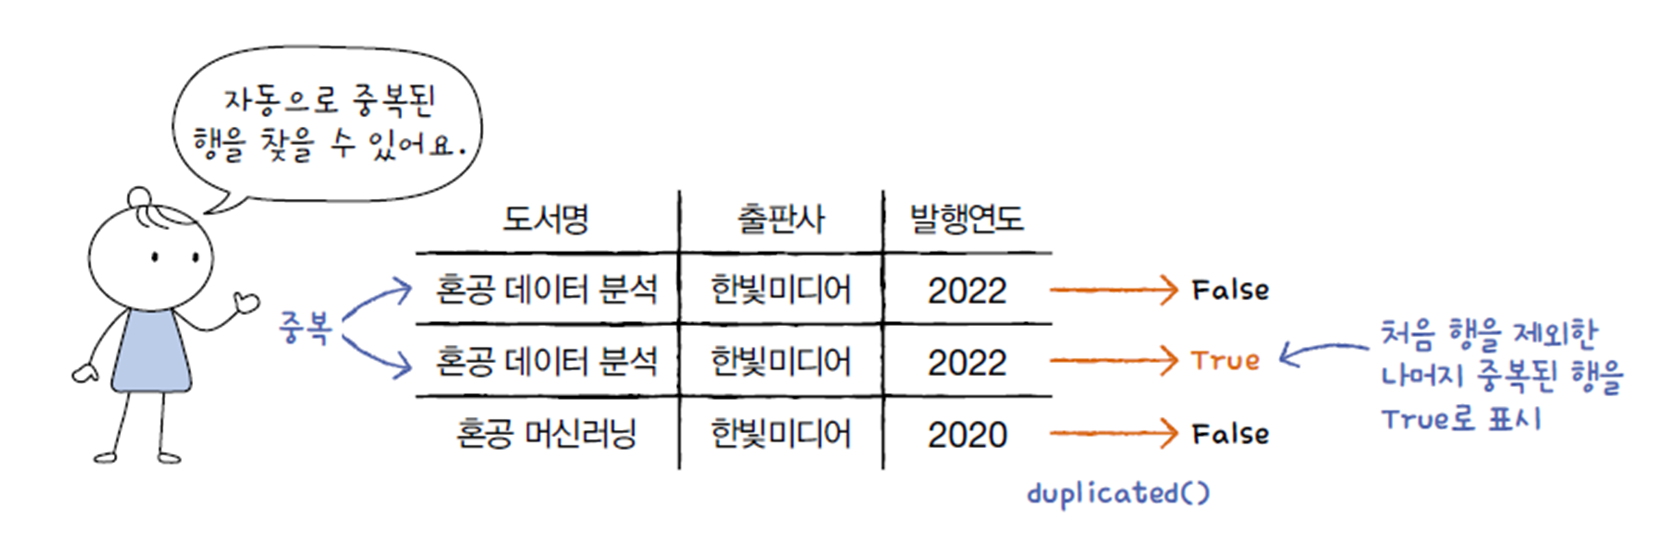

sum() 함수를 함께 사용하면 True를 1로 인식 -> duplicated() 로 만든 불리언 배열에서 중복된 행 개수를 셀 수 있음

In [21]:
sum(ns_book.duplicated()) # 중복된 행의 개수는?

0

sum()함수가 반환한 값이 0인 것을 보니 True로 표시된 행이 하나도 없다! 중복된 행이 없다는 뜻!! 이처럼 duplicated()메서드는 기본적으로 데이터프레임에 있는 모든 열을 기준으로 중복된 행을 찾는다!

근데 모든 행은 고유번호를 갖고 있어서 중복된 행이 나올 수 없음
subset 매개변수에 기준열을 나열해야함

In [22]:
sum(ns_book.duplicated(subset=['도서명','저자','ISBN'])) # 도서명, 저자, isbn 열만 골라서 그 중에서 중복되는 것만 저장

22096

'도서명','저자','ISBN'을 기준으로 어떤 데이터가 중복되었는지 확인해보자! duplicated()메서드에 keep매개변수를 False로 지정하여 중복된 모든 행을 True로 표시합니다. 이 데이터를 ns_book3변수에 저장하여 확인해보자!

In [23]:
dup_rows = ns_book.duplicated(subset=['도서명','저자','ISBN'], keep=False) #중복된 행을 모두 True 표시한 불리언 배열을 반환.
ns_book3 = ns_book[dup_rows]
ns_book3.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
109,110,파친코,이민진 지음 ;이미정 옮김,문학사상,2018,9788970129815,9788970129808,0,1,843.6,1,0,2021-03-12
110,111,파친코,이민진 지음 ;이미정 옮김,문학사상,2018,9788970129822,9788970129808,0,2,843.6,1,0,2021-03-12
111,112,보건교사 안은영 :정세랑 장편소설,지은이: 정세랑,민음사,2021,9788937479953,NaN,0,NaN,813.7,1,0,2021-03-12
112,113,보건교사 안은영 :정세랑 장편소설,지은이: 정세랑,민음사,2021,9788937479953,NaN,0,NaN,813.7,1,1,2021-03-12
113,114,스토너,존 윌리엄스 지음 ;김승욱 옮김,RHK(알에이치코리아),2021,9788925538297,NaN,0,NaN,843.5,1,0,2021-03-12


실행 결과를 확인해보니 첫번째 책 '파친코'는 두 권짜리 도서입니다. 그래서'권'열에 1과 2로 표시됩니다. 두 번째'보건교사 안은영'은 한 권 짜리 도서인데 두 권이 등록되어 있습니다. 아마도 인기가 많아 도서관에서 두권을 구입한 것 같네요.

그룹별로 모으기

어떤 도서가 인기 있을지 예상하려고 하므로 이 데이터 프레임에서 '대출건수'열이 중요!!
같은 도서의 대출건수를 하나로 합치기!!
예를 들어 '혼공 데이터 분석'도서가 두 권이라면 하나로 합치려고 한다.
이럴때 groupby()메서드를 사용!
groupby()메서드의 by매개변수에는 행을 합칠 때 기준이 되는 열을 지정!
권수가 한 개 이상인 도서는 각기 다른 도서로 간주한다.
예를 들어 파친코1권과 2권을 별개의 도서로 본다.
'도서명','출판사','발행연도','대출건수'열을 기준으로 행을 합치면 다음과 같다.
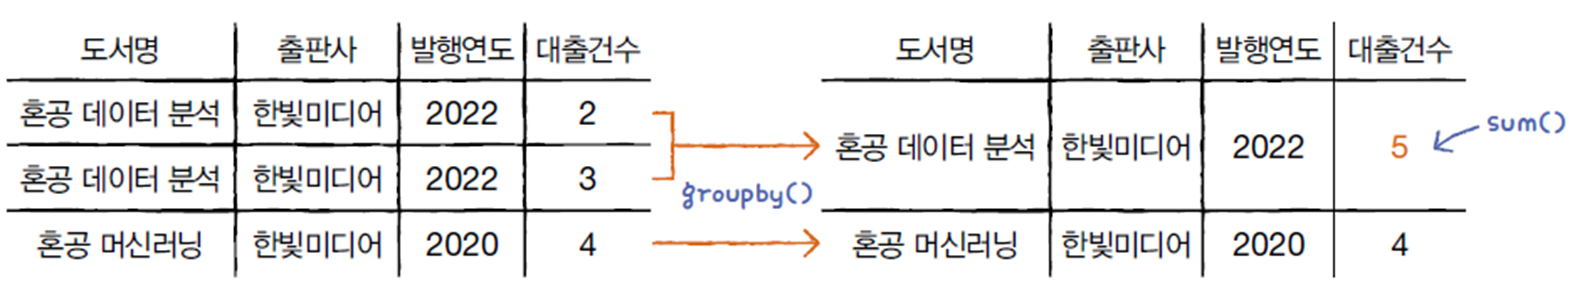

In [24]:
count_df = ns_book[['도서명','저자','ISBN','권','대출건수']] # 묶을 열들
print(count_df)

                          도서명                저자           ISBN    권  대출건수
0                     인공지능과 흙            김동훈 지음  9788937444319  NaN     0
1                가짜 행복 권하는 사회            김태형 지음  9791190123969  NaN     0
2       나도 한 문장 잘 쓰면 바랄 게 없겠네            김선영 지음  9788968332982  NaN     0
3                     예루살렘 해변  이도 게펜 지음, 임재희 옮김  9788970759906  NaN     0
4       김성곤의 중국한시기행 : 장강·황하 편            김성곤 지음  9788934990833  NaN     0
...                       ...               ...            ...  ...   ...
401677                韓國現代詩大系            채만묵 編著  9788977352971    3     0
401678                  뉴 웨이브        제임스 모나코 지음  9788985367448    2     0
401679           (최인훈 장편소설)화두            최인훈 지음  9788937401596    2     0
401680           독일 문학과 세계 문학            吳漢鎭 編著  9788947700368    3     0
401681             참으로 소중한 생각            김일상 지음  9788970610092    1     0

[401682 rows x 5 columns]


결과를 변환한 count_df 데이터프레임에 groupby( ) 메서드를 적용 정수 타입인 ‘대출건수’ 열은 sum( ) 메서드를 사용 NaN이 포함되어 있는 행을 삭제하고 계산하면 대출건수 합계에서 빠지기 때문에 이를 막기 위해 dropna 매개변수를 False로 지정

In [25]:
group_df = count_df.groupby(by=['도서명','저자','ISBN','권'], dropna=False) # groupby() 메서드로 묶고 비어있는 값이 들어있는 행을 삭제X
loan_count = group_df.sum()
print(loan_count)

                                                                                            대출건수
도서명                                             저자                       ISBN          권        
 (꼭 필요한 것부터 쉽게 배우는) 자신만만 블로그 차근차근 배우기           김상현 지음                   9788955025637 NaN    38
 (맨처음 배우는) 세상의 직업                               엘레오노라 바르소티 글 ·그림 ;김태은 옮김 9788992924146 NaN    10
 (영잘원 리스닝과 패턴 영어의 절묘한 만남으로 태어난 ) 리스닝 ABC : 입문편  JD Kim 지음                9788993466089 NaN     4
 (즉석에서 바로바로 활용하는) 일상생활 베트남어 첫걸음                 FL4U컨텐츠 지음               9788971728000 NaN     3
 ,에게                                            이기린(이진희)                 9791196137014 NaN     0
...                                                                                          ...
NaN                                             히라야마 쯔요시 외 5인            9788997924318 NaN     0
                                                ？德峰(Yang Defeng)         9788960716957 NaN     0
                              

In [26]:
loan_count = count_df.groupby(by=['도서명','저자','ISBN','권'], dropna=False).sum() #위에랑 같은 거
loan_count.head()

,,,,대출건수
도서명,저자,ISBN,권,
(꼭 필요한 것부터 쉽게 배우는) 자신만만 블로그 차근차근 배우기,김상현 지음,9788955025637,NaN,38
(맨처음 배우는) 세상의 직업,엘레오노라 바르소티 글 ·그림 ;김태은 옮김,9788992924146,NaN,10
(영잘원 리스닝과 패턴 영어의 절묘한 만남으로 태어난 ) 리스닝 ABC : 입문편,JD Kim 지음,9788993466089,NaN,4
(즉석에서 바로바로 활용하는) 일상생활 베트남어 첫걸음,FL4U컨텐츠 지음,9788971728000,NaN,3
",에게",이기린(이진희),9791196137014,NaN,0


중간고사 범위 끝

In [27]:
dup_rows = ns_book.duplicated(subset=['도서명','저자','ISBN','권']) # 도서명, 저자, isbn, 권 중 중복된 행을 True로
unique_rows = ~dup_rows # ~ 메서드로 불리언 배열 반전해서 고유한 행들을 True로, 중복되지 않은 행을 반환
ns_book3 = ns_book[unique_rows].copy() # 데이터프레임 생성

In [28]:
sum(ns_book3.duplicated(subset=['도서명','저자','ISBN','권'])) # 중복되지 않는 행들에서 중복된 행 확인: 0개

0

In [29]:
ns_book3.set_index(['도서명','저자','ISBN','권'], inplace=True) # 지정한 도서명, 저자, isbn, 권을 인덱스로 세팅
ns_book3.head()

,,,,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
도서명,저자,ISBN,권,,,,,,,,,
인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


In [30]:
ns_book3.update(loan_count) # loan_count의 데이터를 ns_book3 의 데이터에 업데이트
ns_book3.head()

/tmp/ipykernel_7538/3051281402.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  ns_book3.update(loan_count)


,,,,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
도서명,저자,ISBN,권,,,,,,,,,
인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


In [31]:
ns_book4 = ns_book3.reset_index() # 인덱스를 리셋함으로써 도서명, 저자, isbn, 권 인덱스 열을 해제
ns_book4.head()

,도서명,저자,ISBN,권,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
0,인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
1,가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
2,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
3,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
4,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


In [32]:
sum(ns_book['대출건수']>100) # 대출건수가 100 보다 큰 책의 개수

2311

In [33]:
sum(ns_book4['대출건수']>100) # 대출건수가 100 보다 작은 책의 개수

2550

In [34]:
ns_book4 = ns_book4[ns_book.columns] # ns_book 데이터프레임의 열 이름 전달 (번호)
ns_book4.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [35]:
ns_book4.to_csv('ns_book4.csv', index=False) # ns_book4를 csv로 저장

In [36]:
def data_cleaning(filename):
    """
    남산 도서관 장서 CSV 데이터 전처리 함수

    :param filename: CSV 파일이름
    """
    # 파일을 데이터프레임으로 읽습니다.
    ns_df = pd.read_csv(filename, low_memory=False)
    # NaN인 열을 삭제합니다.
    ns_book = ns_df.dropna(axis=1, how='all')

    # 대출건수를 합치기 위해 필요한 행만 추출하여 count_df 데이터프레임을 만듭니다.
    count_df = ns_book[['도서명','저자','ISBN','권','대출건수']]
    # 도서명, 저자, ISBN, 권을 기준으로 대출건수를 groupby합니다.
    loan_count = count_df.groupby(by=['도서명','저자','ISBN','권'], dropna=False).sum()
    # 원본 데이터프레임에서 중복된 행을 제외하고 고유한 행만 추출하여 복사합니다.
    dup_rows = ns_book.duplicated(subset=['도서명','저자','ISBN','권'])
    unique_rows = ~dup_rows
    ns_book3 = ns_book[unique_rows].copy()
    # 도서명, 저자, ISBN, 권을 인덱스로 설정합니다.
    ns_book3.set_index(['도서명','저자','ISBN','권'], inplace=True)
    # load_count에 저장된 누적 대출건수를 업데이트합니다.
    ns_book3.update(loan_count)

    # 인덱스를 재설정합니다.
    ns_book4 = ns_book3.reset_index()
    # 원본 데이터프레임의 열 순서로 변경합니다.
    ns_book4 = ns_book4[ns_book.columns]

    return ns_book4

In [37]:
new_ns_book4 = data_cleaning('ns_202104.csv')

ns_book4.equals(new_ns_book4) # equals(): 다른 데이터프레임과 동일한지 비교

/tmp/ipykernel_7538/1618903035.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  ns_book3.update(loan_count)


True